In [1]:
#segments

cc= ['TEAM', 'STOCK', 'HED',  'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'STUDENT']

dc = [ 'ACROBAT DC',  'ACROBAT CC' ]

all_segment = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'PDF SERVICES', 'SIGN', 'STUDENT']

dme = ['TEAM', 'STOCK', 'HED', 'ACROBAT DC', 'INDIVIDUAL', 'PHOTOGRAPHY', 'K12+EEA', 'ACROBAT CC', 'STUDENT']

In [2]:
import os 
import numpy as np
import pandas as pd

#daily sales by geo and product segment 
os.chdir('/Users/ppavuluri/Desktop/panel_exp-main')
raw_data = pd.read_pickle('/Users/ppavuluri/Desktop/panel_exp-main/raw_data')

raw_data_cc = raw_data[raw_data.cc_segment.isin(cc)]
raw_data_dc = raw_data[raw_data.cc_segment.isin(dc)]

raw_data_cc = raw_data_cc.groupby(['date','geo'])['response1'].sum().reset_index()
raw_data_cc['geo'] = raw_data_cc['geo'].astype('str')
raw_data_cc.head()

,date,geo,response1
0,2022-07-11,500,3112.560000
1,2022-07-11,501,138807.113224
2,2022-07-11,502,737.640000
3,2022-07-11,503,17055.480000
4,2022-07-11,504,35413.748062


# Greedy Market Match class modified to work with Panel data package

In [3]:
# Installing Panel Exp package 

import os
os.chdir('/Users/ppavuluri/Desktop/panel_exp-main')

%run setup.py bdist_wheel

running bdist_wheel
running build
running build_py
installing to build/bdist.macosx-10.9-universal2/wheel
running install
running install_lib
creating build/bdist.macosx-10.9-universal2/wheel
creating build/bdist.macosx-10.9-universal2/wheel/panel_exp
copying build/lib/panel_exp/plot.py -> build/bdist.macosx-10.9-universal2/wheel/panel_exp
copying build/lib/panel_exp/util.py -> build/bdist.macosx-10.9-universal2/wheel/panel_exp
copying build/lib/panel_exp/__init__.py -> build/bdist.macosx-10.9-universal2/wheel/panel_exp
copying build/lib/panel_exp/panel_data.py -> build/bdist.macosx-10.9-universal2/wheel/panel_exp
copying build/lib/panel_exp/impact.py -> build/bdist.macosx-10.9-universal2/wheel/panel_exp
running install_egg_info
running egg_info
writing panel_exp.egg-info/PKG-INFO
writing dependency_links to panel_exp.egg-info/dependency_links.txt
writing requirements to panel_exp.egg-info/requires.txt
writing top-level names to panel_exp.egg-info/top_level.txt
reading manifest file 'p

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: latest is an invalid version and will not be supported in a future release
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/setuptools/installer.py:27: SetuptoolsDeprecationWarning: setuptools.installer is deprecated. Requirements should be satisfied by a PEP 517 installer.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/setuptools/command/install.py:34: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(


adding 'panel_exp-0.1.0.dist-info/RECORD'
removing build/bdist.macosx-10.9-universal2/wheel


In [4]:
pip install "/Users/ppavuluri/Desktop/panel_exp-main/dist/panel_exp-0.1.0-py3-none-any.whl"

Processing ./dist/panel_exp-0.1.0-py3-none-any.whl
panel-exp is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.

[notice] A new release of pip is available: 23.0.1 -> 23.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
from panel_exp.panel_data import PanelDataset, TimePeriod, long_df_to_paneldataset
from panel_exp.design.assign import Design
from typing import Dict, List, NewType, Optional, Tuple, Union
from itertools import chain 

# datatypes for panel data times and units
Unit = NewType("Unit", Union[str, int])

class greedy_match_markets(Design):

    # Market Matches algorithm based on Greedy Search and correlation score 
    # Concept: in each iteration this algo adds a new DMA to control or one of the test groups, 
    # by maximizing the function (correlation_score, rmse_score etc. between control and test groups)
    def assign_all(self, wide_data: pd.DataFrame, num_units: int, num_timepoints: int) -> np.array:
        raise Exception()


    def assign(
        self,
        panel_data: PanelDataset,
        treatment_period: Optional[TimePeriod] = None,
        control_whitelist: Optional[List[Unit]] = None,
        test_whitelist: Optional[List[Unit]] = None,
        control_blacklist: Optional[List[Unit]] = None,
        test_blacklist: Optional[List[Unit]] = None,
        control_test_blacklist: Optional[List[Unit]] = None) -> np.ndarray:

        def corr_func(df, x, y):
            return np.abs(np.corrcoef(df[x].sum(axis=1), df[y].sum(axis=1))[0][1])

        data = panel_data.wide_data.reset_index().melt(id_vars='geo')
        n_grps = 1
        func_to_optimize = corr_func
        sales_df = panel_data.wide_data.T.copy()
        ref_aa_score = -np.inf
        matched_market_pairs = []

        if control_test_blacklist is not None:
            dma_list = list(set(sales_df.columns) - set(control_test_blacklist))
        else:
            dma_list = list(set(sales_df.columns))

        np.random.shuffle(dma_list)

        #initializing test and control groups with random dmas assignment
        r = {}
        if len(control_whitelist) > 0:
            r['control'] = [control_whitelist[0]]
        else:
            r['control'] = [dma_list[0]]

        if len(test_whitelist) > 0:
            r['test_0'] = [test_whitelist[0]]
        else:
            r['test_0'] = [dma_list[1]]

        for c in dma_list:
            if c not in list(set(chain(*list([r['control']] + [r[g] for g in ['test_%s' % _ for _ in range(n_grps)]])))):
                tracker = {'g_%s' % _: None for _ in range(n_grps+1)}
                
                if (control_whitelist is not None or test_blacklist is not None) and (c in control_whitelist or c in test_blacklist):
                    start = 0 
                    end = 1
                    
                elif (test_whitelist is not None or control_blacklist is not None) and (c in test_whitelist or c in control_blacklist):

                    start = 1 
                    end = n_grps+1

                elif (control_test_blacklist is not None) and (c in control_test_blacklist):
                    start = 0 
                    end = 0
                    
                else:
                    start = 0
                    end = n_grps+1

                # print(c,start,end)
                    
                for pointer in range(start,end): # try adding market to each group, which one improves score the most if at all 
                    ctrl = r['control'].copy()
                    g1 = [r['test_%s' % k].copy() for k in range(n_grps)]
                    groups = [ctrl] + g1
                    groups[pointer] = np.append(groups[pointer], c)

                    scores = []
                    for _ in range(1,n_grps+1):
                        scores.append(abs(np.mean(np.array(func_to_optimize(sales_df,groups[0],groups[_])))))

                    avg_score = np.mean(scores)

                    if (avg_score > ref_aa_score):
                        tracker = {'g_%s' % _: groups[_] for _ in range(n_grps+1)}.copy()
                        ref_aa_score = avg_score 
                    # print(c,ref_aa_score,avg_score)

                if tracker['g_0'] is not None:
                    r['control'] = list(str(int(i)) if (type(i)==float or type(i)==int) else i for i in tracker['g_0'])
                    for _ in range(1, n_grps+1):
                        r['test_%s' % str(int(_)-1)] = list(str(int(i)) if (type(i)==float or type(i)==int) else i for i in tracker['g_%s' % _])
                    r['avg_score'] = [ref_aa_score]

                r['control_share'] = [sales_df[r['control']].sum(axis=1).sum()/sales_df.sum(axis=1).sum()]
                r['test_grps_share'] = [sales_df[r['test_%s' %_]].sum(axis=1).sum() for _ in range(n_grps)]/sales_df.sum(axis=1).sum()
                r['test_share'] = [sum(r['test_grps_share'])]
                
        matched_market_pairs.append(r.copy()) 
        
        #trim panel dataset with test and control geos identified above
        mm_trmd_data = data[data.geo.isin(matched_market_pairs[0]['control'] + matched_market_pairs[0]['test_0'])]
        panel_data = long_df_to_paneldataset(mm_trmd_data, "date", "geo", "value",matched_market_pairs[0]['test_0'],[treatment_period.start]*len(matched_market_pairs[0]['test_0']),[treatment_period.end]*len(matched_market_pairs[0]['test_0']))
        panel_data.wide_data = panel_data.wide_data.fillna(0)
        
        return panel_data

# Sensitivity & AA test module

In [29]:
from panel_exp.panel_data import PanelDataset, long_df_to_paneldataset
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair
from panel_exp.methods.SCM.scm import SyntheticControl, AugSynth
from panel_exp.methods.DID import DID
from panel_exp.panel_data import TimePeriod
from sklearn.linear_model import RidgeCV
from sklearn.tree import DecisionTreeRegressor
import datetime
import numpy as np
from matplotlib import pyplot as plt  
import seaborn as sns
import sys

from typing import Dict, List, NewType, Callable, Optional, Tuple, Union
Unit = NewType("Unit", Union[str, int])

    
class sensitivity_aa_module():
    
    def __init__(self, 
             panel_data: PanelDataset, 
             design: Callable,
             estimator: Callable,
             treatment_probability : Optional[float] = 0.5, 
             mm_trim : Optional[int] = 0,
             control_whitelist: Optional[List[Unit]] = [],
             test_whitelist: Optional[List[Unit]] = [],
             control_blacklist: Optional[List[Unit]] = [],
             test_blacklist: Optional[List[Unit]] = [],
             control_test_blacklist: Optional[List[Unit]] = []):
    
        self.panel_data = panel_data #daily geo level sales
        self.design = design
        self.estimator = estimator
        self.treatment_probability = treatment_probability #percent of units to select as treatment group
        self.mm_trim = mm_trim # apply greedy matching markets on top of selected design
        self.control_whitelist = control_whitelist
        self.test_whitelist = test_whitelist
        self.control_blacklist = control_blacklist
        self.test_blacklist = test_blacklist
        self.control_test_blacklist = control_test_blacklist
        
        
    def analysis(self,**inference_kwargs):

        design_est = self.design(self.treatment_probability)
        est = self.estimator(**inference_kwargs)
        gm = greedy_match_markets()


        #results placeholders
        self.increments_random_dates_8wk = []
        self.increments_random_dates_6wk = []
        self.increments_random_dates_4wk = []
        self.increments_random_periods_8wk = []
        self.increments_random_periods_6wk = []
        self.increments_random_periods_4wk = []
        self.counterfactuals_random_dates_8wk = []
        self.counterfactuals_random_dates_6wk = []
        self.counterfactuals_random_dates_4wk = []
        self.counterfactuals_random_periods_8wk = []
        self.counterfactuals_random_periods_6wk = []
        self.counterfactuals_random_periods_4wk = []

        self.panel_data.wide_data = self.panel_data.wide_data.fillna(0)  

        if 'greedy_match_markets' in str(design_est):
            self.test_whitelist = np.random.choice(self.panel_data.units, size = round(self.treatment_probability*len(self.panel_data.units)), replace=False).tolist()
            self.design_data = design_est.assign(self.panel_data,treatment_period=TimePeriod(self.panel_data.wide_data.columns.min(),self.panel_data.wide_data.columns.max()),test_whitelist=self.test_whitelist,control_whitelist=self.control_whitelist,control_blacklist=self.control_blacklist,test_blacklist=self.test_blacklist,control_test_blacklist=self.control_test_blacklist)

        if 'greedy_match_markets' not in str(design_est):
            
            #exit function if whitelist/blacklist values are passed and the design is not greedy_match_markets            
            if len(self.test_whitelist)!=0 or len(self.test_blacklist)!=0 or len(self.control_whitelist)!=0 or len(self.control_blacklist)!=0 or len(self.control_test_blacklist)!=0:
                
                print('use greedy_match_market if you would like to whitelist/blacklist')
                sys.exit(0)
            
            else: #continue execution only if no whitelist/blacklist values are passed  
                
                self.design_data = design_est.assign(self.panel_data,treatment_period=TimePeriod(self.panel_data.wide_data.columns.min(),self.panel_data.wide_data.columns.max()))
                
                if self.mm_trim == 1:  #trim control units identified by selected design using MM algo
                    self.design_data = gm.assign(self.panel_data,treatment_period=TimePeriod(self.panel_data.wide_data.columns.min(),self.panel_data.wide_data.columns.max()),test_whitelist=self.design_data.treated_units,control_whitelist=self.control_whitelist,control_blacklist=self.control_blacklist,test_blacklist=self.test_blacklist,control_test_blacklist=self.control_test_blacklist)
                        
        
        print('calculating counterfactuals(y_hat) and incrementals(y-y_hat) for randomly selected dates of size 56,42 and 28 days \n')
        
        for _ in range(20):

            print('iteration %s' %_)

            for test_length in [56,42,28]:
                
                #selecting random dates of given test length from available timeline 
                test_dates = np.random.choice(self.panel_data.wide_data.columns.sort_values().unique()[:-56], size=test_length, replace=False)
                test_dates = [datetime.datetime.strptime(dt, "%Y-%m-%d") for dt in test_dates]
                test_dates.sort()
                test_dates = [datetime.datetime.strftime(dt, "%Y-%m-%d") for dt in test_dates]

                #re-arranging wide_data df so that all randomly selected treated dates are sorted and moved to the end of columns to accomodate for split_control_test_units logic
                self.design_data.wide_data = pd.concat([self.design_data.wide_data.loc[:,~self.design_data.wide_data.columns.isin(test_dates)], self.design_data.wide_data.loc[:,test_dates]], axis=1)
                self.design_data.wide_data = self.design_data.wide_data.fillna(0)

                #re-intializing paneldatset to update location indexes for treated_periods that got moved in previous step 
                self.design_data = PanelDataset(wide_data = self.design_data.wide_data, treated_periods = [TimePeriod(test_dates[0],test_dates[-1])]*len(self.design_data.treated_units), treated_units = self.design_data.treated_units)

                est_select = est
                est_select.run_analysis(self.design_data,treatment_aggregation_fun='sum')

                if test_length == 56:
                    self.increments_random_dates_8wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_dates_8wk.append(est_select.results['y_hat'].sum())
                elif test_length == 42:
                    self.increments_random_dates_6wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_dates_6wk.append(est_select.results['y_hat'].sum())
                elif test_length == 28:
                    self.increments_random_dates_4wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_dates_4wk.append(est_select.results['y_hat'].sum())

        
        print('\n calculating counterfactuals(y_hat) and incrementals(y-y_hat) for randomly selected periods of size 56,42 and 28 days \n')
    
        for _ in range(20):

            print('iteration %s' %_)

            for test_length in [56,42,28]:

                #selecting random periods of given test length from available timeline 
                test_start_dt = pd.to_datetime(np.random.choice(self.panel_data.wide_data.columns.sort_values().unique()[:-56], size=1, replace=False), format='%Y-%m-%d').strftime('%Y-%m-%d')
                test_end_dt = pd.to_datetime(test_start_dt, format='%Y-%m-%d') + datetime.timedelta(days=test_length)
                test_end_dt = test_end_dt.strftime('%Y-%m-%d')
                test_dates = [(pd.to_datetime(test_start_dt[0], format='%Y-%m-%d') + datetime.timedelta(days=day)).strftime('%Y-%m-%d') for day in range(test_length+1)]

                #re-arranging wide_data df so that all randomly selected treated dates are sorted and moved to the end of columns to accomodate for split_control_test_units logic
                self.design_data.wide_data = pd.concat([self.design_data.wide_data.loc[:,~self.design_data.wide_data.columns.isin(test_dates)], self.design_data.wide_data.loc[:,test_dates]], axis=1)
                self.design_data.wide_data = self.design_data.wide_data.fillna(0)

                #re-intializing paneldatset to update location indexes for treated_periods that got moved in previous step 
                self.design_data = PanelDataset(wide_data = self.design_data.wide_data, treated_periods = [TimePeriod(test_dates[0],test_dates[-1])]*len(self.design_data.treated_units), treated_units = self.design_data.treated_units)

                est_select = est

                est_select.run_analysis(self.design_data,treatment_aggregation_fun='sum')

                if test_length == 56:
                    self.increments_random_periods_8wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_periods_8wk.append(est_select.results['y_hat'].sum())
                elif test_length == 42:
                    self.increments_random_periods_6wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_periods_6wk.append(est_select.results['y_hat'].sum())
                elif test_length == 28:
                    self.increments_random_periods_4wk.append(est_select.results['y'].sum() - est_select.results['y_hat'].sum())
                    self.counterfactuals_random_periods_4wk.append(est_select.results['y_hat'].sum())
                
                
    def yhat_dist_summary(self):
        
        pd.options.display.float_format = '{:.2f}'.format

        return pd.DataFrame([[round(np.mean(self.counterfactuals_random_dates_8wk)),
                      round(np.mean(self.counterfactuals_random_dates_6wk)),round(np.mean(self.counterfactuals_random_dates_4wk))],
                     [1.64 *round(np.std(self.counterfactuals_random_dates_8wk)),1.64*round(np.std(self.counterfactuals_random_dates_6wk)),1.64 *round(np.std(self.counterfactuals_random_dates_4wk))],
                      [1.64*100*round(np.std(self.counterfactuals_random_dates_8wk))/round(np.mean(self.counterfactuals_random_dates_8wk)),1.64*100*round(np.std(self.counterfactuals_random_dates_6wk))/round(np.mean(self.counterfactuals_random_dates_6wk)),1.64*100*round(np.std(self.counterfactuals_random_dates_4wk))/round(np.mean(self.counterfactuals_random_dates_4wk))],
                      [round(np.mean(self.counterfactuals_random_periods_8wk)),
                      round(np.mean(self.counterfactuals_random_periods_6wk)),round(np.mean(self.counterfactuals_random_periods_4wk))],
                     [1.64*round(np.std(self.counterfactuals_random_periods_8wk)),1.64*round(np.std(self.counterfactuals_random_periods_6wk)),1.64*round(np.std(self.counterfactuals_random_periods_4wk))],
                      [1.64*100*round(np.std(self.counterfactuals_random_periods_8wk))/round(np.mean(self.counterfactuals_random_periods_8wk)),1.64*100*round(np.std(self.counterfactuals_random_periods_6wk))/round(np.mean(self.counterfactuals_random_periods_6wk)),1.64*100*round(np.std(self.counterfactuals_random_periods_4wk))/round(np.mean(self.counterfactuals_random_periods_4wk))]],
                     columns = ['8wk','6wk','4wk'], index = ['random_dates_yhat','random_dates_ci_90','random_dates_mde%','random_periods_yhat','random_periods_ci_90','random_periods_mde%'])

    
    def aa_test_dist_summary(self):
        
        return pd.DataFrame([[100 - pd.Series([increments <= (np.mean(self.increments_random_dates_8wk) + 1.64 * np.std(self.increments_random_dates_8wk) ) and increments >= (np.mean(self.increments_random_dates_8wk) - 1.64 * np.std(self.increments_random_dates_8wk)) for increments in self.increments_random_dates_8wk]).value_counts()[True]*100/len(self.increments_random_dates_8wk),
                       100 - pd.Series([increments <= (np.mean(self.increments_random_dates_6wk) + 1.64 * np.std(self.increments_random_dates_6wk) ) and increments >= (np.mean(self.increments_random_dates_6wk) - 1.64 * np.std(self.increments_random_dates_6wk)) for increments in self.increments_random_dates_6wk]).value_counts()[True]*100/len(self.increments_random_dates_6wk),
                       100 - pd.Series([increments <= (np.mean(self.increments_random_dates_4wk) + 1.64 * np.std(self.increments_random_dates_4wk) ) and increments >= (np.mean(self.increments_random_dates_4wk) - 1.64 * np.std(self.increments_random_dates_4wk)) for increments in self.increments_random_dates_4wk]).value_counts()[True]*100/len(self.increments_random_dates_4wk)],
                      [100 - pd.Series([increments <= (np.mean(self.increments_random_periods_8wk) + 1.64 * np.std(self.increments_random_periods_8wk) ) and increments >= (np.mean(self.increments_random_periods_8wk) - 1.64 * np.std(self.increments_random_periods_8wk)) for increments in self.increments_random_periods_8wk]).value_counts()[True]*100/len(self.increments_random_periods_8wk),
                       100 - pd.Series([increments <= (np.mean(self.increments_random_periods_6wk) + 1.64 * np.std(self.increments_random_periods_6wk) ) and increments >= (np.mean(self.increments_random_periods_6wk) - 1.64 * np.std(self.increments_random_periods_6wk)) for increments in self.increments_random_periods_6wk]).value_counts()[True]*100/len(self.increments_random_periods_6wk),
                       100 - pd.Series([increments <= (np.mean(self.increments_random_periods_4wk) + 1.64 * np.std(self.increments_random_periods_4wk) ) and increments >= (np.mean(self.increments_random_periods_4wk) - 1.64 * np.std(self.increments_random_periods_4wk)) for increments in self.increments_random_periods_4wk]).value_counts()[True]*100/len(self.increments_random_periods_4wk)],
                      [np.mean(self.increments_random_dates_8wk),np.mean(self.increments_random_dates_6wk),np.mean(self.increments_random_dates_4wk)],
                      [np.mean(self.increments_random_periods_8wk),np.mean(self.increments_random_periods_6wk),np.mean(self.increments_random_periods_4wk)]],
                     columns = ['8wk','6wk','4wk'], index=['random_dates_false_positive_rate%','random_periods_false_positive_rate%','random_dates_mean_increments','random_periods_mean_increments'])
    
    
    def test_control_markets(self):
        
        return pd.DataFrame([[list(set(self.design_data.units.tolist()) - set(self.design_data.treated_units)),self.design_data.treated_units, 
                            len(list(set(self.design_data.units.tolist()) - set(self.design_data.treated_units))),
                            len(self.design_data.treated_units)]],
            columns = ['control','test','control_len','test_len'])
    
    
    def yhat_dist_plot(self):
        
        fig, ax = plt.subplots(1,2, figsize=(15,5))
        colors = ['green','orange', 'red']

        for i,increments in enumerate(zip(['8wk','6wk','4wk'],[self.counterfactuals_random_dates_8wk, self.counterfactuals_random_dates_6wk, self.counterfactuals_random_dates_4wk])):
            sns.kdeplot(increments[1], ax = ax[0], color = colors[i])
            ax[0].axvline(np.mean(increments[1]), ls='dashdot', color = colors[i], label = increments[0]+'_mean')
            ax[0].axvline(np.mean(increments[1])+ 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_lower_ci')
            ax[0].axvline(np.mean(increments[1])- 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_upper_ci')

        ax[0].legend()
        ax[0].set_title('y-hat for randomly selected dates')

        for i, increments in enumerate(zip(['8wk','6wk','4wk'],[self.counterfactuals_random_periods_8wk, self.counterfactuals_random_periods_6wk, self.counterfactuals_random_periods_4wk])):
            sns.kdeplot(increments[1], ax = ax[1], color = colors[i])
            ax[1].axvline(np.mean(increments[1]), ls='dashdot', color = colors[i], label = increments[0]+'_mean')
            ax[1].axvline(np.mean(increments[1])+ 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_lower_ci')
            ax[1].axvline(np.mean(increments[1])- 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_upper_ci')
        ax[1].legend()
        ax[1].set_title('y-hat for randomly selected periods')
        
        
        
    def aa_test_dist_plot(self):
        
        fig, ax = plt.subplots(1,2, figsize=(15,5))
        colors = ['green','orange', 'red']

        for i,increments in enumerate(zip(['8wk','6wk','4wk'],[self.increments_random_dates_8wk, self.increments_random_dates_6wk, self.increments_random_dates_4wk])):
            sns.kdeplot(increments[1], ax = ax[0], color = colors[i])
            ax[0].axvline(np.mean(increments[1]), ls='dashdot', color = colors[i], label = increments[0]+'_mean')
            ax[0].axvline(np.mean(increments[1])+ 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_lower_ci')
            ax[0].axvline(np.mean(increments[1])- 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_upper_ci')

        ax[0].legend()
        ax[0].set_title('AA results for randomly selected dates')

        for i, increments in enumerate(zip(['8wk','6wk','4wk'],[self.increments_random_periods_8wk, self.increments_random_periods_6wk, self.increments_random_periods_4wk])):
            sns.kdeplot(increments[1], ax = ax[1], color = colors[i])
            ax[1].axvline(np.mean(increments[1]), ls='dashdot', color = colors[i], label = increments[0]+'_mean')
            ax[1].axvline(np.mean(increments[1])+ 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_lower_ci')
            ax[1].axvline(np.mean(increments[1])- 1.64 * np.std(increments[1]), ls='dotted', color=colors[i], label = increments[0]+'_upper_ci')
        ax[1].legend()
        ax[1].set_title('AA results for randomly selected periods')
        
        


In [30]:
from panel_exp.design import CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, MatchedPair
from panel_exp.methods.SCM.scm import SyntheticControl, AugSynth
from panel_exp.methods.DID import DID

panel_dataset = long_df_to_paneldataset(raw_data_cc, "date", "geo", "response1")
designs = [CompleteRandomization, ThinningDesign, Rerandomization, QuickBlock, greedy_match_markets][0]
estimators = [DID, SyntheticControl, AugSynth][2]

results = sensitivity_aa_module(panel_data = panel_dataset,design = designs,estimator = estimators,mm_trim=1)

##whitelist/blacklist option with greedy_match_markets
# results = sensitivity_aa_module(panel_data = panel_dataset, design = designs,estimator = estimators, test_whitelist = ['803','642','570'], test_blacklist = [geo for geo in panel_dataset.units if geo not in ['803','642','570']])

results.analysis(inference=None, treatment_aggregation_fun='sum', outcome_model=RidgeCV, alphas=[1e-3, 1e-2, 1e-1, 1])


calculating counterfactuals(y_hat) and incrementals(y-y_hat) for randomly selected dates of size 56,42 and 28 days 

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19

 calculating counterfactuals(y_hat) and incrementals(y-y_hat) for randomly selected periods of size 56,42 and 28 days 

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 11
iteration 12
iteration 13
iteration 14
iteration 15
iteration 16
iteration 17
iteration 18
iteration 19


In [31]:
results.test_control_markets()

,control,test,control_len,test_len
0,"[592, 693, 698, 541, 547, 627, 544, 513, 506, ...","[501, 598, 543, 600, 717, 691, 611, 514, 881, ...",67,97


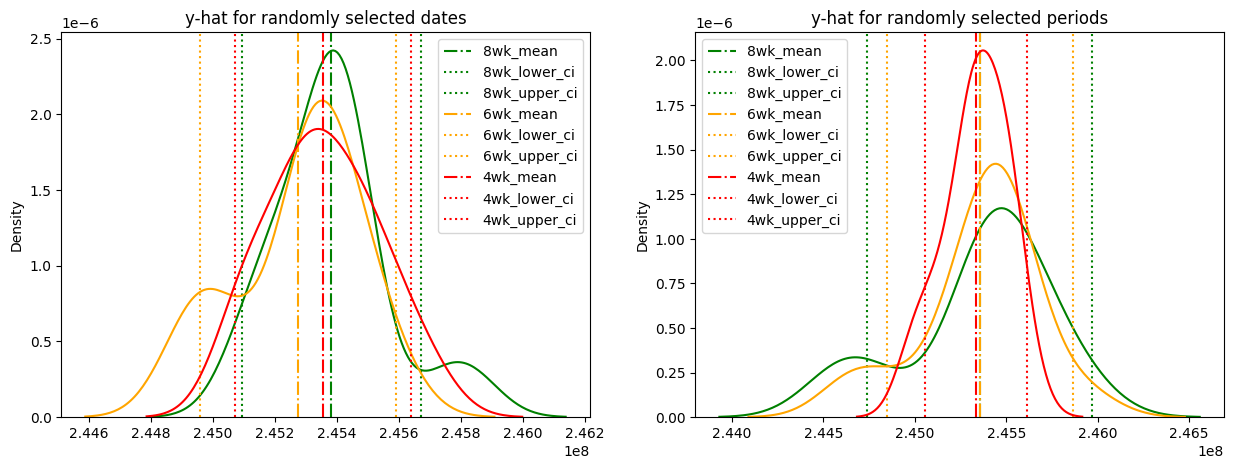

In [34]:
results.yhat_dist_plot()

In [35]:
results.yhat_dist_summary()

,8wk,6wk,4wk
random_dates_yhat,245381944.00,245275013.00,245355514.00
random_dates_ci_90,287639.60,315736.08,283529.76
random_dates_mde%,0.12,0.13,0.12
random_periods_yhat,245354582.00,245358486.00,245336442.00
random_periods_ci_90,616946.68,509121.60,279439.60
random_periods_mde%,0.25,0.21,0.11


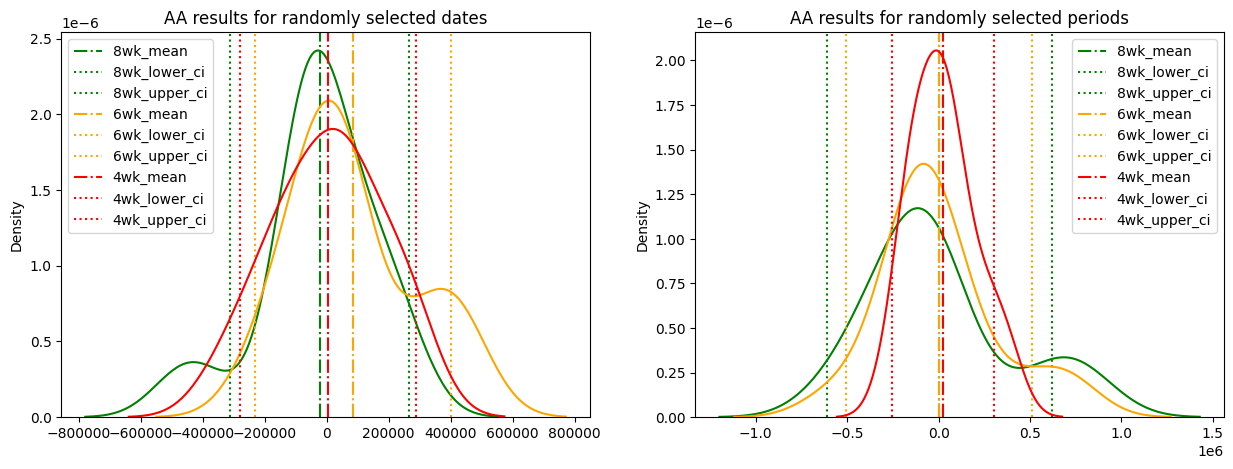

In [36]:
results.aa_test_dist_plot()

In [37]:
results.aa_test_dist_summary()

,8wk,6wk,4wk
random_dates_false_positive_rate%,10.00,10.00,5.00
random_periods_false_positive_rate%,15.00,15.00,15.00
random_dates_mean_increments,-22759.00,84172.19,3670.90
random_periods_mean_increments,4602.87,699.21,22742.93
